In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from sklearn.metrics import ndcg_score
import scipy.stats as stats
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ndcg_score
import scipy.stats as stats
from datetime import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

In [4]:
csv_path = "tables\\zaModel.csv" 
df = pd.read_csv(csv_path)
# nedostajuce vrednosti popunjene sa -1
df = df.fillna(-1)

In [5]:
df = df.drop('Unnamed: 0', axis=1)

In [6]:
df.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'constructor', 'grid', 'driverId', 'race_name', 'circuit', 'lap_length',
       'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5',
       'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms'],
      dtype='object')

In [7]:
# kolone koje se prosledjuju modelu
feat_cols = ['season', 'round', 'drivers_num', 'position_quali',
       'constructor', 'grid', 'driverId', 'race_name', 'circuit', 'lap_length',
       'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5',
       'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']
label_col = 'position_race'

In [8]:
#label enkodovanje imena staze, trke i konctruktora, id-ja vozaca
le = LabelEncoder()
df["circuit"] = le.fit_transform(df["circuit"])
le = LabelEncoder()
df["driverId"] = le.fit_transform(df["driverId"])
le = LabelEncoder()
df["race_name"] = le.fit_transform(df["race_name"])
le = LabelEncoder()
df["constructor"] = le.fit_transform(df["constructor"])


In [9]:
# Ucitavanje podataka

# izbaciti redove za koje se ne zna ime i pozicija vozaca
df = df.dropna(subset=["position_race", "race_name"])

# Umesto nan vrednosti stavlja se -1
df["position_quali"] = df["position_quali"].fillna(-1)


# pravimo group id-jeve po sezoni i rundi
df["group_id"] = df["season"].astype(str) + "_" + df["round"].astype(str)

# uklanjamo target kolonu i group_id jer se on koristi samo za split 
features = df.drop(columns=["position_race", "group_id"])
target = 21 - df["position_race"]

# Hronoloski split
unique_races_sorted = (
    df[["season", "round", "group_id"]]
    .drop_duplicates()
    .sort_values(["season", "round"])
)["group_id"].values

In [10]:
features.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'constructor',
       'grid', 'driverId', 'race_name', 'circuit', 'lap_length',
       'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5',
       'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms'],
      dtype='object')

In [11]:
# parametri preuzeti od treniranja jednog modela
params = {'eta': 0.2887307937626501, 
               'max_depth': 9, 
               'min_child_weight': 7, 
               'gamma': 1.532449837441483, 
               'subsample': 0.8629518668797063, 
               'colsample_bytree': 0.7980549693999068, 
               'lambda': 0.5779815313531302, 
               'alpha': 0.21037705351193614, 
               'objective': 'rank:pairwise', 
               'eval_metric': 'ndcg'}

In [12]:
step_size = 6
train_size = 30
val_size = 2
test_size = 4

In [13]:
# pocetni index-i
train_idx = 0
valid_idx = train_idx + val_size * 20
test_idx = valid_idx + test_size * 20

In [14]:
# folder u kom ce da se cuvaju modeli
timern = datetime.now().strftime('%d-%m-%Y_%H-%M-%S')
path = f'models_camp\\xgboost\\rolling window\\{timern}'
os.mkdir(path)

In [15]:
window_size = train_size

In [16]:
model = None 

In [17]:
ndcg_all = []
tau_all = []
spearman_all = []
rmse_all = []

In [18]:
len(df)

2960

In [19]:
from sklearn.metrics import ndcg_score, root_mean_squared_error


for window_start in range(0, (len(df) // 20) - window_size - val_size - test_size + 1, step_size):
    train_idx = window_start
    valid_idx = train_idx + window_size
    test_idx = valid_idx + val_size

    train_races = unique_races_sorted[train_idx : valid_idx]
    val_races = unique_races_sorted[valid_idx : test_idx]
    test_races = unique_races_sorted[test_idx : test_idx + test_size]

    train_mask = df["group_id"].isin(train_races)
    val_mask = df["group_id"].isin(val_races)
    test_mask = df["group_id"].isin(test_races)

    X_train = features[train_mask]
    y_train = target[train_mask]
    X_val = features[val_mask]
    y_val = target[val_mask]
    X_test = features[test_mask]
    y_test = target[test_mask]

    group_sizes_train = df[train_mask].groupby("group_id").size().values
    group_sizes_val = df[val_mask].groupby("group_id").size().values
    group_sizes_test = df[test_mask].groupby("group_id").size().values

    # pravljenje DMatrixa koji je optimizovan za xgboost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtrain.set_group(group_sizes_train)

    dval = xgb.DMatrix(X_val, label=y_val)
    dval.set_group(group_sizes_val)

    dtest = xgb.DMatrix(X_test, label=y_test)
    dtest.set_group(group_sizes_test)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=50,
        xgb_model=model,  # prethodni model
        early_stopping_rounds=10, 
        evals=[(dval, "validation")]
    )

    # Predikcije modela
    y_pred_scores = model.predict(dtest)

    df_test = df[test_mask].copy()
    df_test["pred_score"] = y_pred_scores

    df_test['position_race'] = pd.to_numeric(df_test['position_race'], errors='coerce')
    df_test['pred_score'] = pd.to_numeric(df_test['pred_score'], errors='coerce')

    race_groups = df_test.groupby("group_id")

    # Metrike
    ndcg_list = []
    tau_list = []
    spearman_list = []
    rmse_list = []

    for race_id, group in race_groups:
        if group.shape[0] < 2:
            continue  # preskacu se trke sa manje od dva vozaca

        true_ranks = group["position_race"].values
        pred_scores = group["pred_score"].values

        # relevantnost 21 - pozicija, jer ndcg ocekuje vece = bolje
        true_relevance = 21 - true_ranks
        ndcg = ndcg_score([true_relevance], [pred_scores])
        ndcg_list.append(ndcg)

        # Kendall's Tau i Spearman
        tau, _ = stats.kendalltau(-true_ranks, pred_scores)
        spearman, _ = stats.spearmanr(-true_ranks, pred_scores)
        tau_list.append(tau)
        spearman_list.append(spearman)

        # RMSE između predikcije i stvarne pozicije
        rmse = root_mean_squared_error(true_ranks, -pred_scores)
        rmse_list.append(rmse)

    # Sabiranje metrika po rolling window-u
    ndcg_all.append(np.mean(ndcg_list))
    tau_all.append(np.nanmean(tau_list))
    spearman_all.append(np.nanmean(spearman_list))
    rmse_all.append(np.mean(rmse_list))

    print(f"Evaluation Metrics Across Races:")
    print(f"Average NDCG: {np.mean(ndcg_list):.4f}")
    print(f"Average Kendall's Tau: {np.nanmean(tau_list):.4f}")
    print(f"Average Spearman: {np.nanmean(spearman_list):.4f}")
    print(f"Average RMSE: {np.mean(rmse_list):.4f}")
    print("-" * 50)

# Završni pregled
print("Ukupne prosečne metrike kroz sve prozore:")
print(f"Final average NDCG: {np.mean(ndcg_all):.4f}")
print(f"Final average Kendall's Tau: {np.nanmean(tau_all):.4f}")
print(f"Final average Spearman: {np.nanmean(spearman_all):.4f}")
print(f"Final average RMSE: {np.mean(rmse_all):.4f}")


[0]	validation-ndcg:0.61718
[1]	validation-ndcg:0.72854
[2]	validation-ndcg:0.85158
[3]	validation-ndcg:0.84788
[4]	validation-ndcg:0.87652
[5]	validation-ndcg:0.88571
[6]	validation-ndcg:0.90998
[7]	validation-ndcg:0.91646
[8]	validation-ndcg:0.91646
[9]	validation-ndcg:0.91623
[10]	validation-ndcg:0.91660
[11]	validation-ndcg:0.92083
[12]	validation-ndcg:0.92083
[13]	validation-ndcg:0.92083
[14]	validation-ndcg:0.92083
[15]	validation-ndcg:0.92083
[16]	validation-ndcg:0.92083
[17]	validation-ndcg:0.92083
[18]	validation-ndcg:0.92083
[19]	validation-ndcg:0.92083
[20]	validation-ndcg:0.92095
[21]	validation-ndcg:0.92095
[22]	validation-ndcg:0.92095
[23]	validation-ndcg:0.92095
[24]	validation-ndcg:0.92095
[25]	validation-ndcg:0.92095
[26]	validation-ndcg:0.92095
[27]	validation-ndcg:0.92095
[28]	validation-ndcg:0.92095
[29]	validation-ndcg:0.92095
Evaluation Metrics Across Races:
Average NDCG: 0.9678
Average Kendall's Tau: 0.5297
Average Spearman: 0.6885
Average RMSE: 11.9438
---------

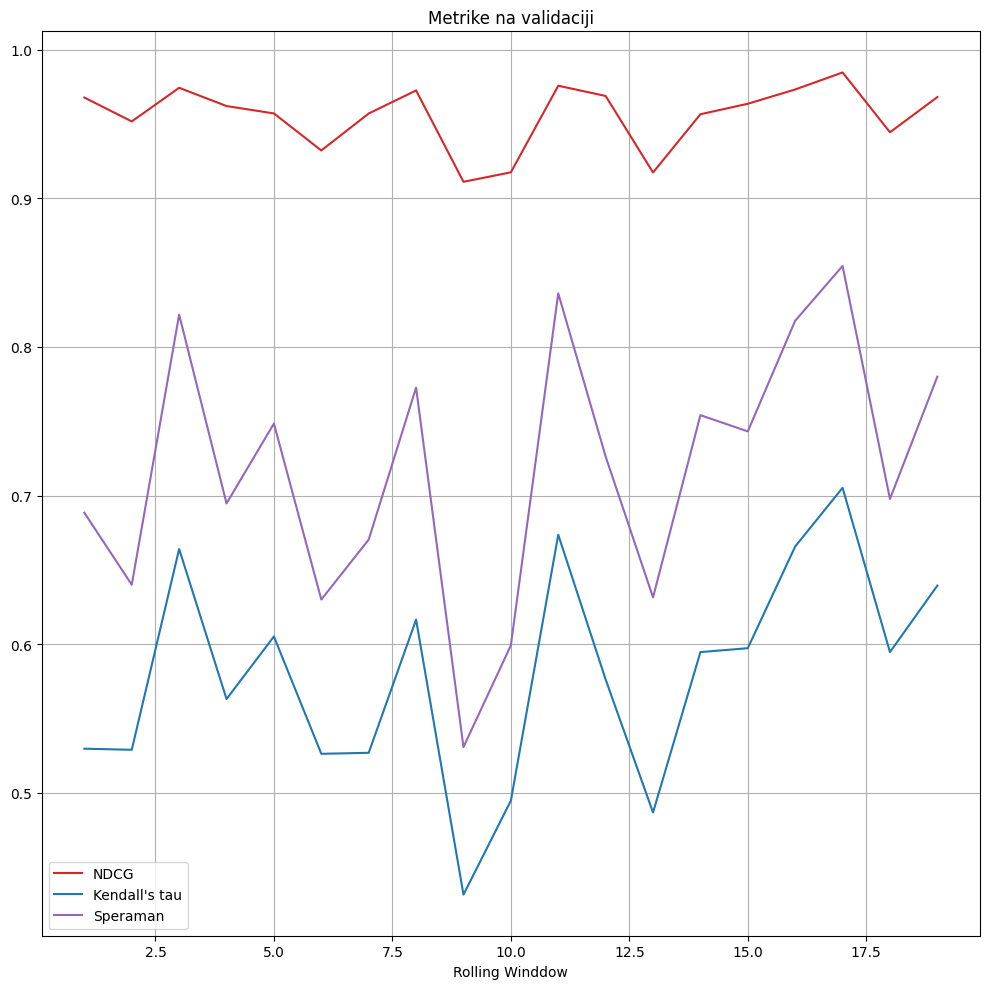

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(ndcg_all) + 1))

fig, axs = plt.subplots(1, 1, figsize=(10, 10), sharex=True)

# Prvi subplot – Loss
axs.plot(epochs, ndcg_all, label='NDCG', color='tab:red', linestyle='-')
axs.plot(epochs, tau_all, label='Kendall\'s tau', color='tab:blue', linestyle='-')
axs.plot(epochs, spearman_all, label='Speraman', color='tab:purple', linestyle='-')
axs.set_xlabel('Rolling Winddow')
axs.set_title(f'Metrike na validaciji')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()


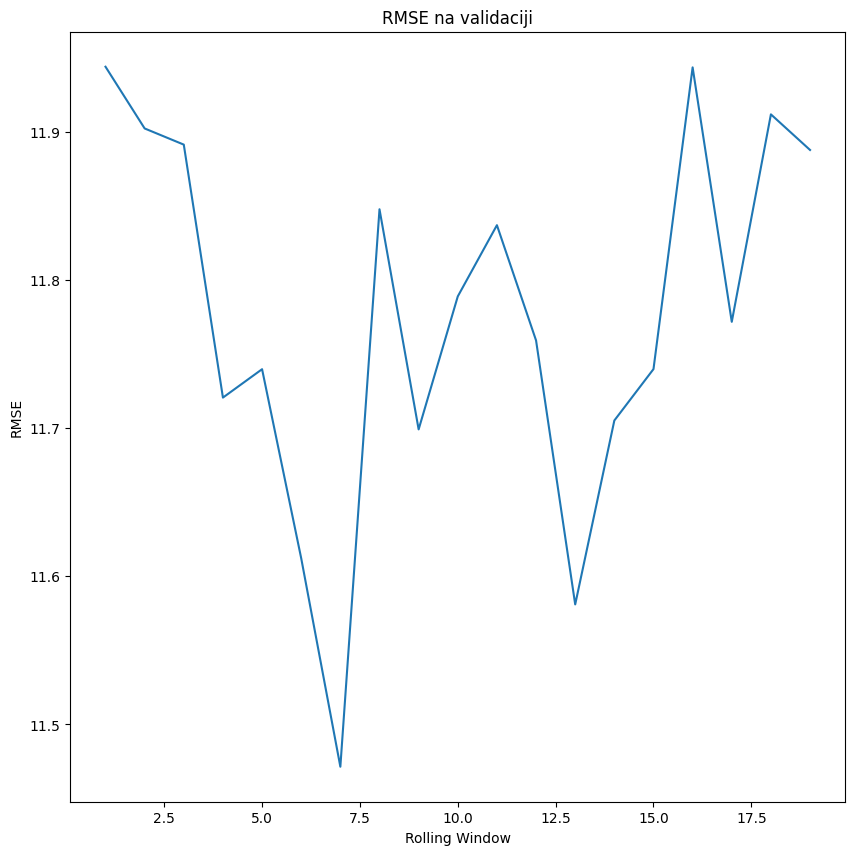

In [24]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10), sharex=True)
axs.set_title(f'RMSE na validaciji')
axs.set_xlabel('Rolling Window')
axs.set_ylabel('RMSE')
axs.plot(epochs, rmse_all)

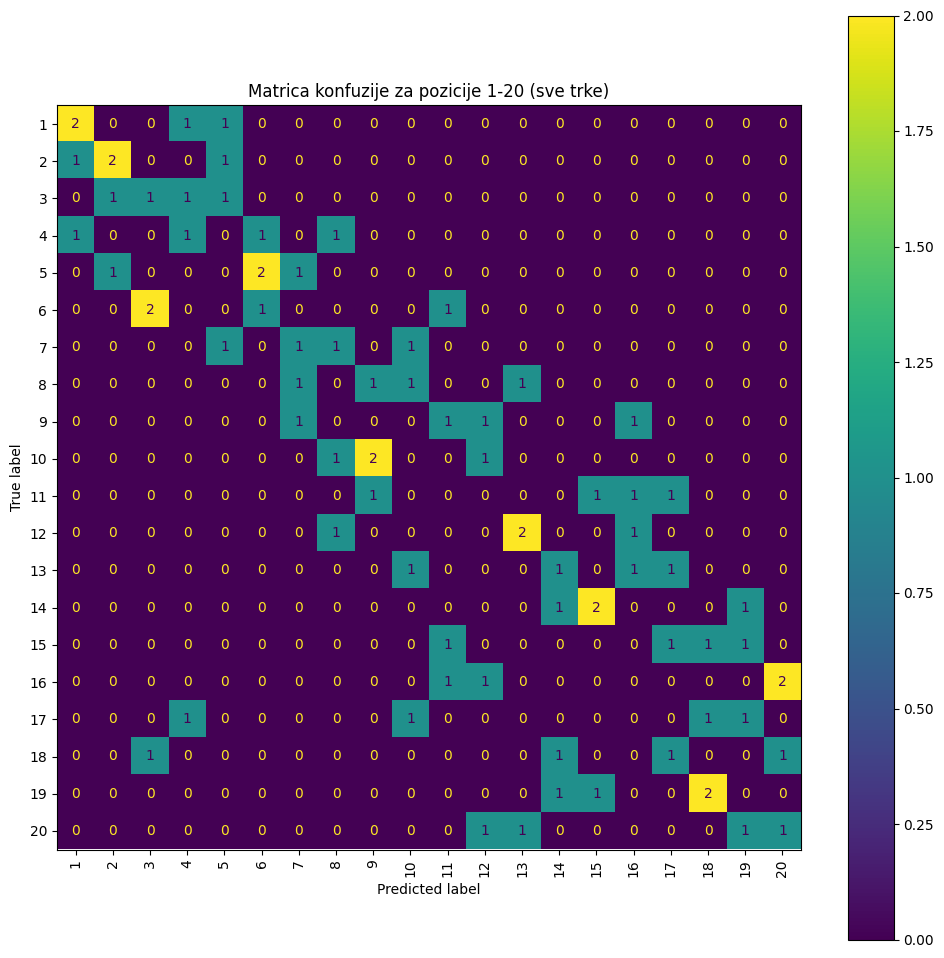

In [ ]:

# lista za sve predikcije 
y_pred_all = []
y_true_all = []

for race_id, group in df_test.groupby("group_id"):
    if len(group) < 2:
        continue

    group = group.copy()
    # Stvarna pozicija
    y_true = group["position_race"].astype(int).values

    # Predikovana pozicija - rangiranje
    pred_ranks = group["pred_score"].rank(ascending=False, method='first').astype(int).values

    # Dodaj u ukupne liste
    y_true_all.extend(y_true)
    y_pred_all.extend(pred_ranks)

# Definiši klase (1 do 20)
labels = list(range(1, 21))

# Napravi matricu konfuzije
cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)

# Prikaži matricu konfuzije
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()
